# 05. 도로타입 × 도로번호 딥다이브

03번 노트북에서는 도로타입 전체, 도로번호 전체를 각각 따로 살펴봤다. 이 노트북은 원본
보고서의 "도로타입 × 도로번호 교차 분석"을 7개 도로타입 전체로 확장해, **도로타입별로
상위 도로(번호)마다 돌발구분 구성비가 얼마나 다른지**를 본다.

**참고**: `특별광역시도`와 `시군도`는 데이터상 `도로번호`가 항상 `0`으로 기록되어 있어
(다수의 일반 도로가 하나의 코드로 합쳐짐) 도로번호 기준 분해가 의미가 없다. 이 두
도로타입만 `도로명` 기준 상위 20개로 대체했다.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load
from src.plot_config import set_korean_style

set_korean_style()
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load(with_region=False)
df.shape

(623188, 18)

## 5.1 도로타입별 상위 도로 Top 20 돌발구분 구성비

도로타입별로 발생 건수 상위 20개 도로(고속국도/국가지원지방도/도시고속국도/지방도/
일반국도는 도로번호 기준, 특별광역시도/시군도는 도로명 기준)를 뽑아, 그 도로에서
돌발구분(공사/교통사고/기상/기타/기타돌발/재난)이 차지하는 비중(%)을 히트맵으로 본다.

In [2]:
ROAD_TYPES_BY_NUMBER = ['고속국도', '국가지원지방도', '도시고속국도', '지방도', '일반국도']
ROAD_TYPES_BY_NAME = ['시군도', '특별광역시도']
FILE_SLUGS = {
    '고속국도': 'expressway', '특별광역시도': 'metro_arterial', '일반국도': 'national_road',
    '도시고속국도': 'urban_expressway', '시군도': 'city_road', '지방도': 'local_road',
    '국가지원지방도': 'gov_local_road',
}


def top20_composition(road_type: str, key_col: str) -> pd.DataFrame:
    sub = df[df['도로타입'] == road_type].copy()
    if key_col == '도로번호':
        sub[key_col] = sub[key_col].dropna().astype(int).astype(str)
    top20 = sub[key_col].value_counts().head(20).index
    sub = sub[sub[key_col].isin(top20)]
    comp = pd.crosstab(sub[key_col], sub['돌발구분'], normalize='index') * 100
    return comp.reindex(top20)


def plot_composition(road_type: str, key_col: str, fig_num: int):
    comp = top20_composition(road_type, key_col)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(comp))))
    sns.heatmap(comp, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '비중 (%)'}, ax=ax)
    ax.set_title(f'{road_type}: 상위 {len(comp)}개 {key_col}별 돌발구분 구성비 (%)')
    ax.set_ylabel(key_col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'{fig_num}_road_top20_{FILE_SLUGS[road_type]}.png', dpi=150)
    plt.show()
    return comp

### 고속국도

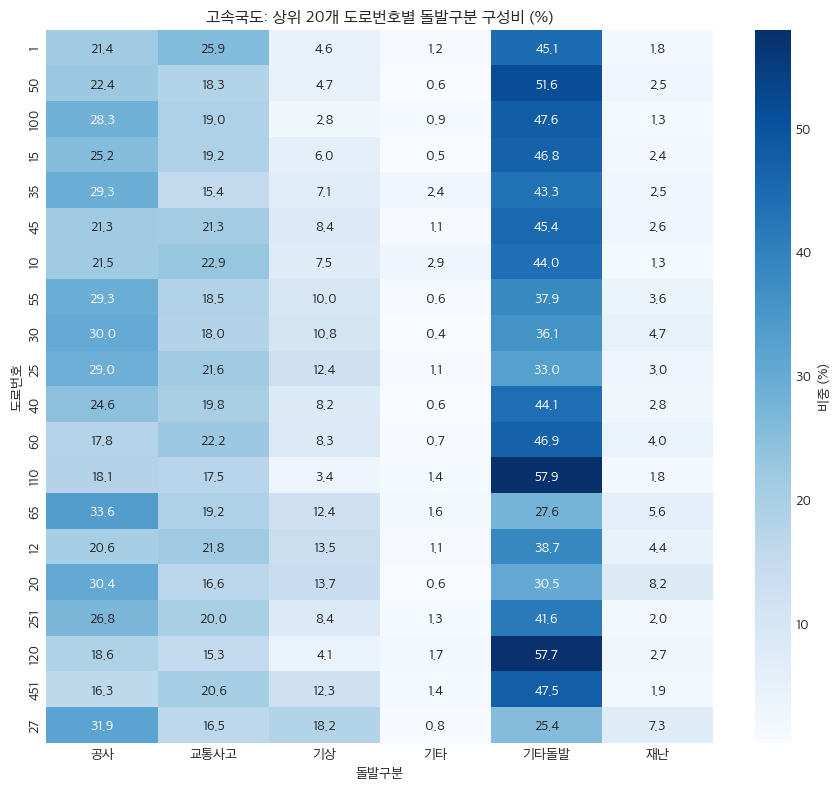

돌발구분,공사,교통사고,기상,기타,기타돌발,재난
도로번호,,,,,,
1,21.391289,25.948507,4.577686,1.162332,45.082387,1.837800
50,22.378575,18.250113,4.736723,0.574217,51.609169,2.451203
100,28.330827,19.016773,2.822441,0.890688,47.606709,1.332562
15,25.159058,19.177541,5.958297,0.541030,46.779362,2.384712
35,29.252748,15.430984,7.108715,2.408519,43.308195,2.490839
45,21.281713,21.254615,8.386682,1.087288,45.418826,2.570877
10,21.455426,22.930374,7.475960,2.866749,43.962837,1.308654
55,29.324475,18.531190,10.021483,0.612667,37.945576,3.564609
30,30.047940,18.005935,10.769319,0.365255,36.108892,4.702660


In [3]:
plot_composition('고속국도', '도로번호', 14)

### 특별광역시도

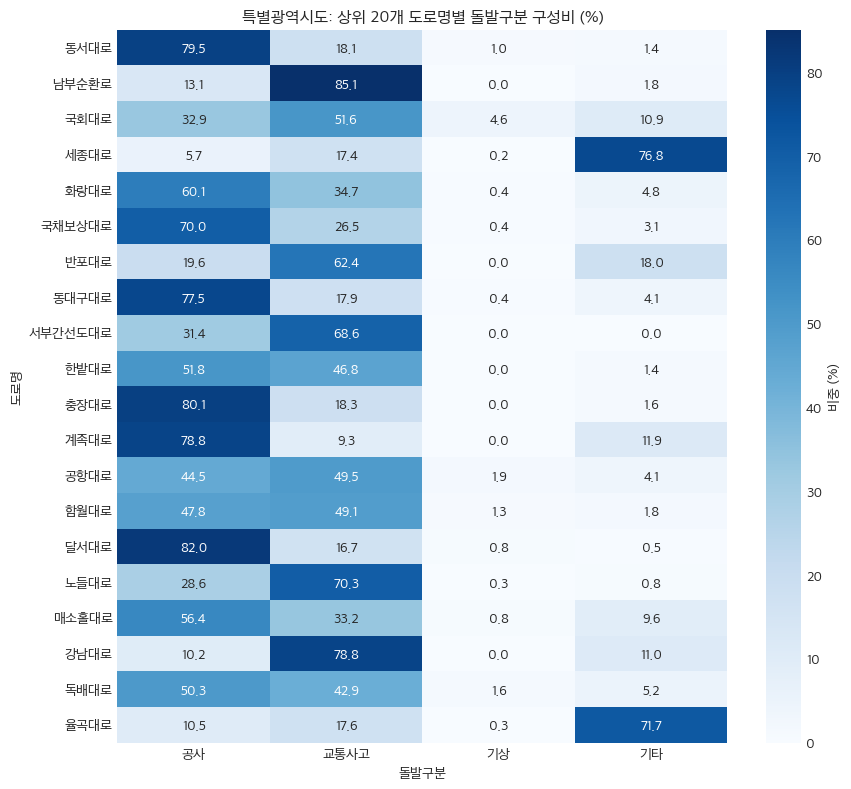

돌발구분,공사,교통사고,기상,기타
도로명,,,,
동서대로,79.525593,18.102372,0.998752,1.373283
남부순환로,13.089802,85.083714,0.000000,1.826484
국회대로,32.937182,51.612903,4.584041,10.865874
세종대로,5.667276,17.367459,0.182815,76.782450
화랑대로,60.110294,34.742647,0.367647,4.779412
국채보상대로,70.000000,26.470588,0.392157,3.137255
반포대로,19.628099,62.396694,0.000000,17.975207
동대구대로,77.537797,17.926566,0.431965,4.103672
서부간선도대로,31.359649,68.640351,0.000000,0.000000


In [4]:
plot_composition('특별광역시도', '도로명', 15)

### 일반국도

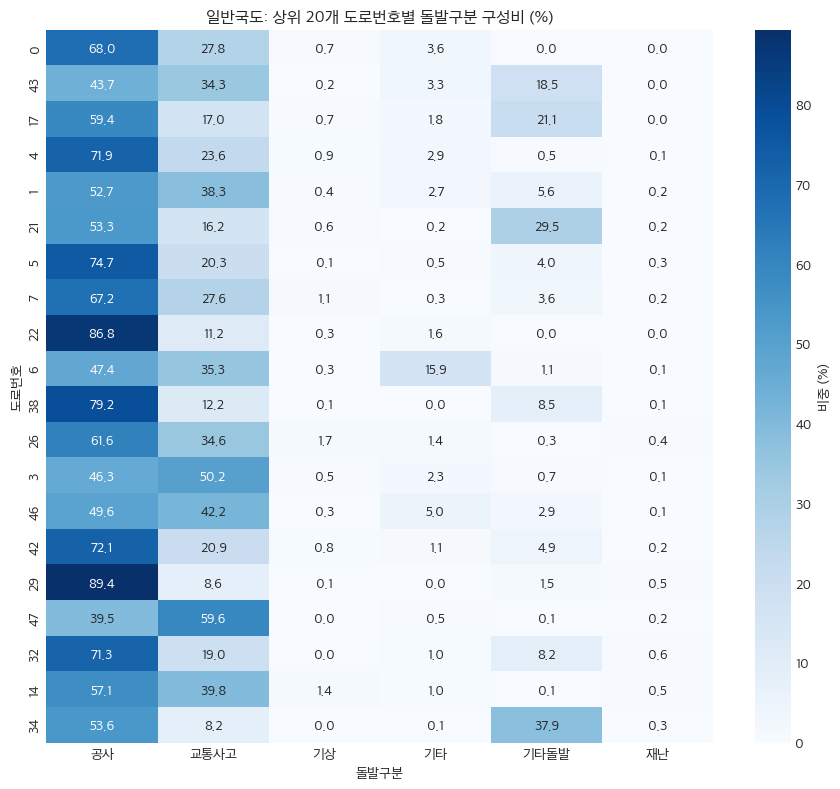

돌발구분,공사,교통사고,기상,기타,기타돌발,재난
도로번호,,,,,,
0,67.961487,27.772244,0.680611,3.585657,0.000000,0.000000
43,43.725910,34.261242,0.171306,3.297645,18.543897,0.000000
17,59.352837,17.021277,0.664894,1.817376,21.143617,0.000000
4,71.916509,23.624288,0.948767,2.941176,0.474383,0.094877
1,52.719665,38.284519,0.418410,2.719665,5.648536,0.209205
21,53.271569,16.213086,0.636943,0.231616,29.473075,0.173712
5,74.740933,20.272021,0.129534,0.518135,4.015544,0.323834
7,67.188564,27.569775,1.089176,0.340368,3.607897,0.204221
22,86.843899,11.247444,0.340832,1.567825,0.000000,0.000000


In [5]:
plot_composition('일반국도', '도로번호', 16)

### 도시고속국도

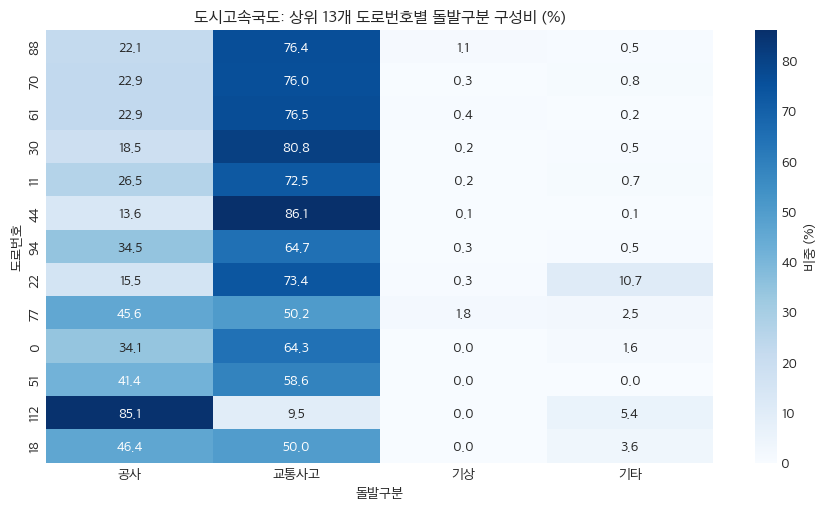

돌발구분,공사,교통사고,기상,기타
도로번호,,,,
88,22.072647,76.372287,1.079262,0.475804
70,22.865538,76.028344,0.259246,0.846872
61,22.851669,76.491516,0.437876,0.218938
30,18.541505,80.837859,0.155159,0.465477
11,26.459627,72.546584,0.248447,0.745342
44,13.594771,86.143791,0.130719,0.130719
94,34.517766,64.720812,0.253807,0.507614
22,15.517241,73.448276,0.344828,10.689655
77,45.614035,50.175439,1.754386,2.456140


In [6]:
plot_composition('도시고속국도', '도로번호', 17)

### 시군도

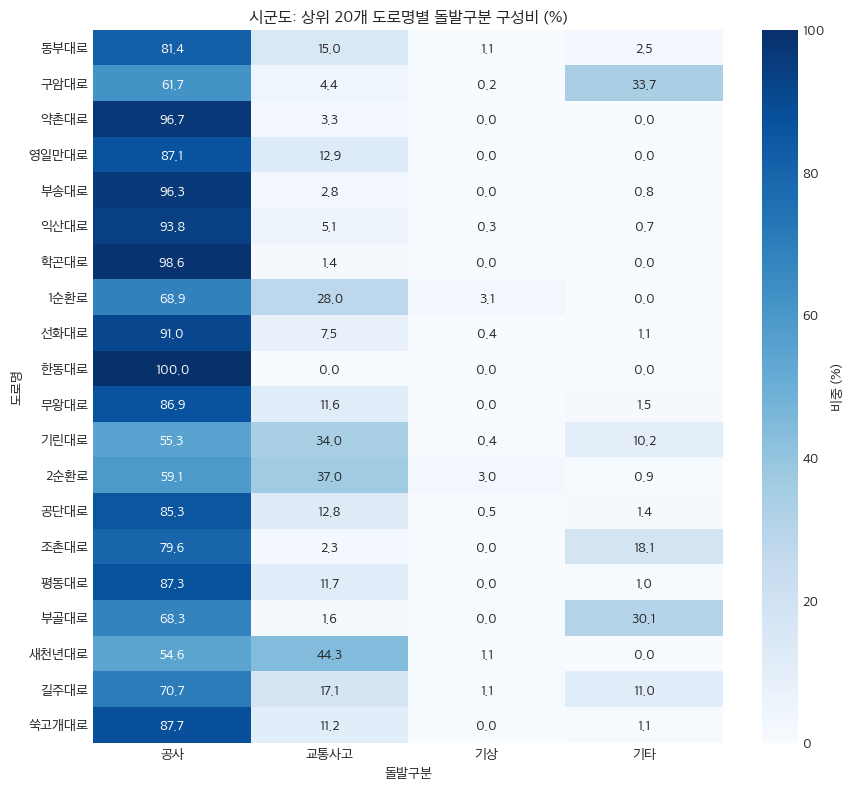

돌발구분,공사,교통사고,기상,기타
도로명,,,,
동부대로,81.372549,15.032680,1.143791,2.450980
구암대로,61.742424,4.356061,0.189394,33.712121
약촌대로,96.730769,3.269231,0.000000,0.000000
영일만대로,87.052342,12.947658,0.000000,0.000000
부송대로,96.317280,2.832861,0.000000,0.849858
익산대로,93.835616,5.136986,0.342466,0.684932
학곤대로,98.606272,1.393728,0.000000,0.000000
1순환로,68.881119,27.972028,3.146853,0.000000
선화대로,91.039427,7.526882,0.358423,1.075269


In [7]:
plot_composition('시군도', '도로명', 18)

### 지방도

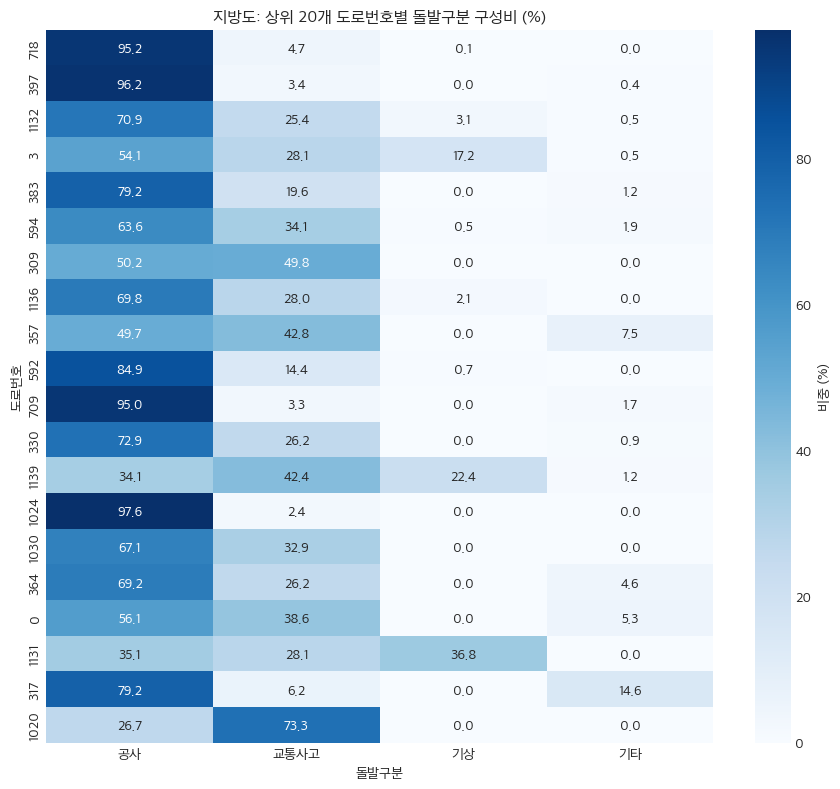

돌발구분,공사,교통사고,기상,기타
도로번호,,,,
718,95.180723,4.698795,0.120482,0.000000
397,96.170839,3.387334,0.000000,0.441826
1132,70.944310,25.423729,3.147700,0.484262
3,54.098361,28.142077,17.213115,0.546448
383,79.200000,19.600000,0.000000,1.200000
594,63.551402,34.112150,0.467290,1.869159
309,50.246305,49.753695,0.000000,0.000000
1136,69.841270,28.042328,2.116402,0.000000
357,49.710983,42.774566,0.000000,7.514451


In [8]:
plot_composition('지방도', '도로번호', 19)

### 국가지원지방도

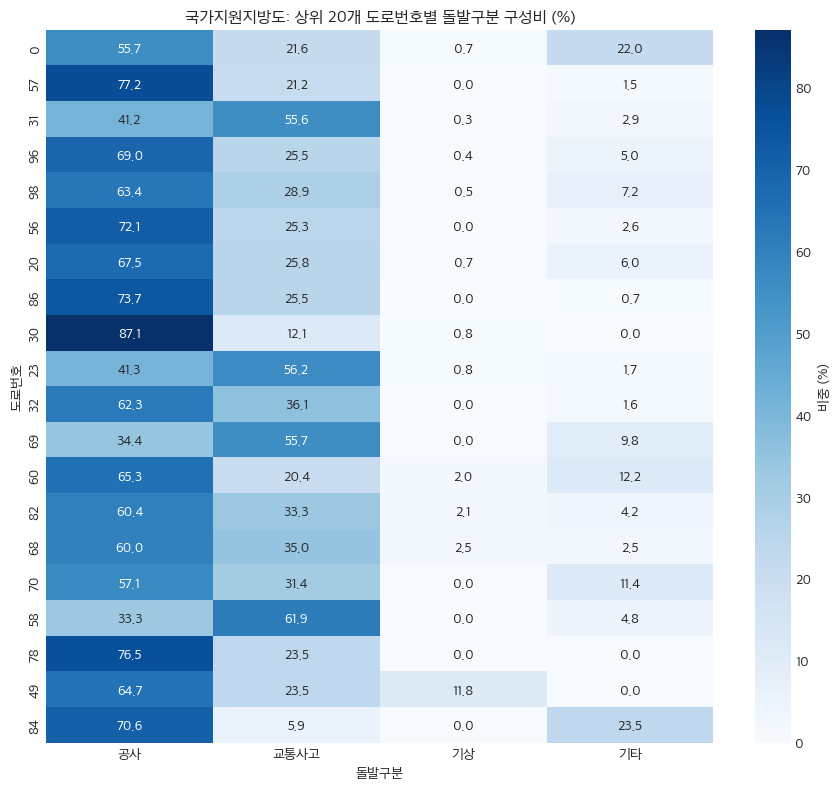

돌발구분,공사,교통사고,기상,기타
도로번호,,,,
0,55.677656,21.611722,0.732601,21.978022
57,77.230769,21.230769,0.000000,1.538462
31,41.176471,55.555556,0.326797,2.941176
96,69.037657,25.523013,0.418410,5.020921
98,63.402062,28.865979,0.515464,7.216495
56,72.077922,25.324675,0.000000,2.597403
20,67.549669,25.827815,0.662252,5.960265
86,73.722628,25.547445,0.000000,0.729927
30,87.096774,12.096774,0.806452,0.000000


In [9]:
plot_composition('국가지원지방도', '도로번호', 20)

## 5.2 도로타입 내 이질성 요약

도로타입 평균만 보면 가려지는, 같은 도로타입 안에서도 유독 특정 돌발구분 비중이 높은
도로(번호/명)를 정리한다 — 도로타입 전체 평균 대비 편차가 가장 큰 조합을 찾는다.

In [10]:
outlier_rows = []
for rt in ["고속국도", "특별광역시도", "일반국도", "도시고속국도", "시군도", "지방도", "국가지원지방도"]:
    key_col = '도로명' if rt in ('특별광역시도', '시군도') else '도로번호'
    comp = top20_composition(rt, key_col)
    type_avg = df.loc[df['도로타입'] == rt, '돌발구분'].value_counts(normalize=True) * 100
    diff = (comp - type_avg.reindex(comp.columns).fillna(0)).abs().max(axis=1)
    top_key = diff.idxmax()
    top_cat = comp.loc[top_key].idxmax()
    outlier_rows.append({
        '도로타입': rt, key_col: top_key, '최다비중 돌발구분': top_cat,
        '해당 도로 비중(%)': round(comp.loc[top_key, top_cat], 1),
        '도로타입 평균(%)': round(type_avg.get(top_cat, 0), 1),
    })

pd.DataFrame(outlier_rows)

,도로타입,도로번호,최다비중 돌발구분,해당 도로 비중(%),도로타입 평균(%),도로명
0,고속국도,27,공사,31.9,25.2,NaN
1,특별광역시도,NaN,기타,76.8,8.8,세종대로
2,일반국도,47,교통사고,59.6,25.8,NaN
3,도시고속국도,112,공사,85.1,22.7,NaN
4,시군도,NaN,공사,61.7,76.4,구암대로
5,지방도,1020,교통사고,73.3,19.8,NaN
6,국가지원지방도,58,교통사고,61.9,29.7,NaN
